# Seismic Event Detection and Phase Picking with 1D U-Net

This notebook implements a unified deep learning model for:
1. **Detection**: Discriminating between seismic noise and earthquake events.
2. **Phase Picking**: Identifying P-wave and S-wave arrival times.

## Approach
We treat this as a **time-series segmentation problem** using a 1D U-Net architecture that outputs probability masks for P and S wave arrivals at each time step.

In [ ]:
#@title Imports & Setup

import os
import random
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd
import seaborn as sns

# Set random seeds for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Global configuration
WINDOW_LENGTH = 6000  # 60 seconds at 100 Hz
BATCH_SIZE = 32
LEARNING_RATE = 1e-3
NUM_EPOCHS = 50
TRAIN_SPLIT = 0.8

Using device: cuda


In [ ]:
#@title Data Loading

DATA_PATH = 'seismic_dataset_balanced.npz'

print(f"Loading preprocessed data from {DATA_PATH}...")

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        f"File '{DATA_PATH}' not found! \n"
        "Please run your data generation script first to create the .npz file."
    )

# Load the data
with np.load(DATA_PATH) as data:
    X = data['waveforms']      # Shape: (N, 3, 6000)
    y_arrivals = data['arrivals'] # Shape: (N, 2)

# Basic verification and statistics
print(f"Data Loaded Successfully.")
print(f"Waveform shape: {X.shape}")
print(f"Labels shape:   {y_arrivals.shape}")

# Count events vs noise based on your script's logic (-1 indicates noise)
n_events = np.sum(y_arrivals[:, 0] >= 0)
n_noise = np.sum(y_arrivals[:, 0] < 0)

print(f"  - Earthquake Events: {n_events}")
print(f"  - Noise Samples:     {n_noise}")

# Safety check: ensure correct data types for PyTorch
X = X.astype(np.float32)
y_arrivals = y_arrivals.astype(np.float32)

# Check for NaNs (sometimes happens with raw seismic data normalization)
if np.isnan(X).any():
    print("WARNING: NaNs found in waveform data. Replacing with 0.")
    X = np.nan_to_num(X)

Loading preprocessed data from seismic_dataset_balanced.npz...
Data Loaded Successfully.
Waveform shape: (2000, 3, 6000)
Labels shape:   (2000, 2)
  - Earthquake Events: 1000
  - Noise Samples:     1000


In [ ]:
#@title Target Mask Creation

def create_gaussian_mask(arrival_sample, length, sigma=50):
    """Create a Gaussian probability distribution centered on arrival time."""
    if arrival_sample < 0:  # Noise case
        return np.zeros(length, dtype=np.float32)

    x = np.arange(length)
    # Gaussian formula
    mask = np.exp(-0.5 * ((x - arrival_sample) / sigma) ** 2)

    # Normalize peak to 1.0 (probability)
    return mask.astype(np.float32)

def prepare_masks(arrivals, length=WINDOW_LENGTH, sigma=30):
    """Vectorized mask preparation."""
    n_samples = len(arrivals)
    masks_p = np.zeros((n_samples, length), dtype=np.float32)
    masks_s = np.zeros((n_samples, length), dtype=np.float32)

    print("Creating target probability masks...")
    for i in tqdm(range(n_samples)):
        masks_p[i] = create_gaussian_mask(arrivals[i, 0], length, sigma)
        masks_s[i] = create_gaussian_mask(arrivals[i, 1], length, sigma)

    return masks_p, masks_s

# Create masks
masks_p, masks_s = prepare_masks(y_arrivals, WINDOW_LENGTH, sigma=30)

Creating target probability masks...


100%|██████████| 2000/2000 [00:00<00:00, 8900.46it/s]


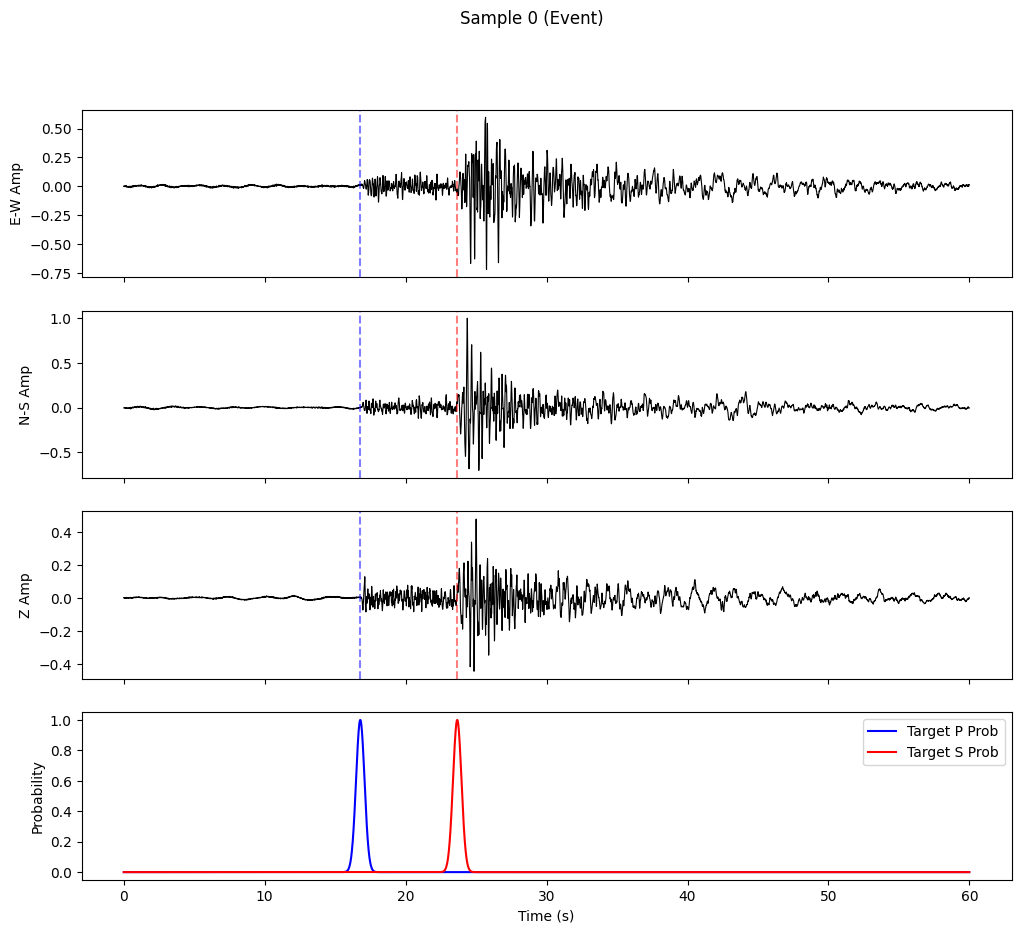

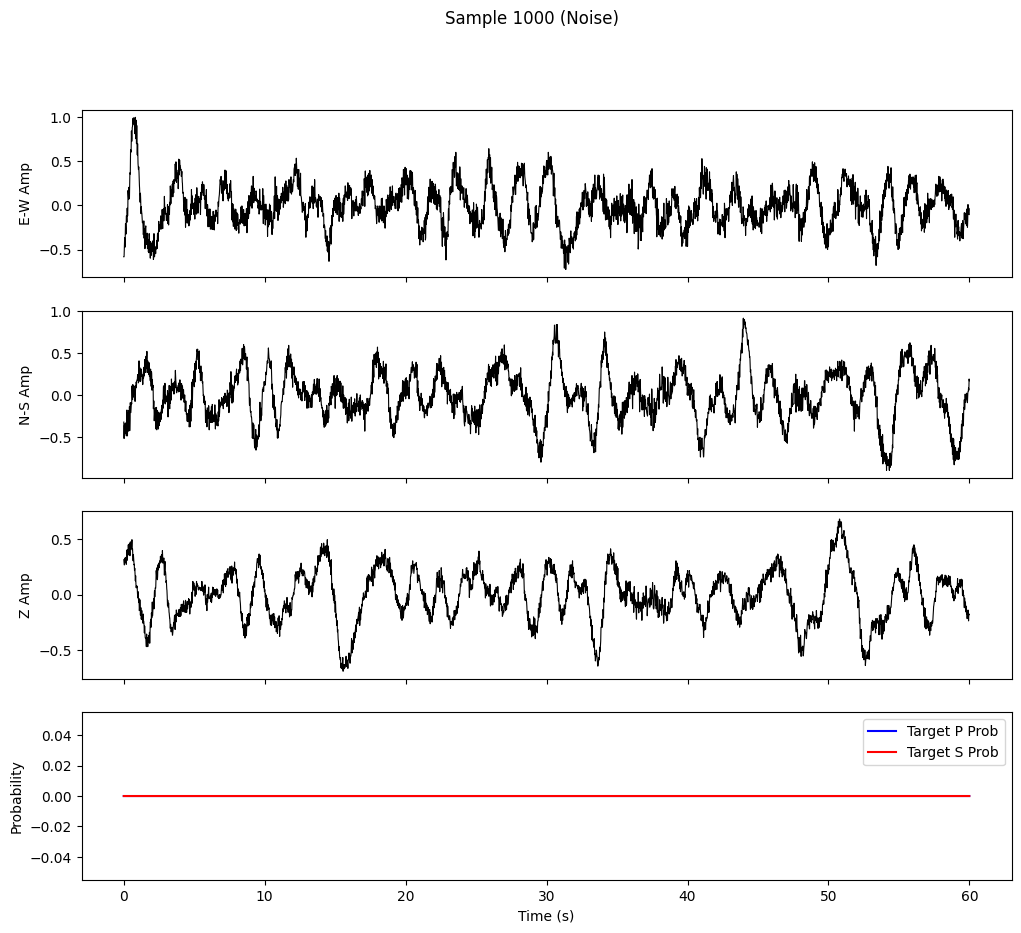

In [ ]:
#@title Visualizing Data

def plot_sample(idx, X, y, mask_p, mask_s):
    fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)
    time = np.arange(WINDOW_LENGTH) / 100.0

    channels = ['E-W', 'N-S', 'Z']
    for i in range(3):
        axes[i].plot(time, X[idx, i], 'k', lw=0.8)
        axes[i].set_ylabel(f"{channels[i]} Amp")

        # Plot ground truth lines
        if y[idx, 0] != -1:
            axes[i].axvline(y[idx, 0]/100, color='b', linestyle='--', alpha=0.5, label='P Pick')
        if y[idx, 1] != -1:
            axes[i].axvline(y[idx, 1]/100, color='r', linestyle='--', alpha=0.5, label='S Pick')

    # Plot Masks
    axes[3].plot(time, mask_p[idx], 'b', label='Target P Prob')
    axes[3].plot(time, mask_s[idx], 'r', label='Target S Prob')
    axes[3].set_ylabel("Probability")
    axes[3].set_xlabel("Time (s)")
    axes[3].legend(loc="upper right")

    plt.suptitle(f"Sample {idx} ({'Event' if y[idx,0] != -1 else 'Noise'})")
    plt.show()

# Visualize an Event and a Noise sample
event_ids = np.where(y_arrivals[:, 0] != -1)[0]
noise_ids = np.where(y_arrivals[:, 0] == -1)[0]

if len(event_ids) > 0: plot_sample(event_ids[0], X, y_arrivals, masks_p, masks_s)
if len(noise_ids) > 0: plot_sample(noise_ids[0], X, y_arrivals, masks_p, masks_s)

In [ ]:
#@title PyTorch Dataset & Loader

class SeismicDataset(Dataset):
    def __init__(self, waveforms, masks_p, masks_s):
        self.waveforms = torch.from_numpy(waveforms).float()
        self.masks_p = torch.from_numpy(masks_p).float()
        self.masks_s = torch.from_numpy(masks_s).float()

    def __len__(self):
        return len(self.waveforms)

    def __getitem__(self, idx):
        return {
            'x': self.waveforms[idx],
            'y_p': self.masks_p[idx],
            'y_s': self.masks_s[idx]
        }

# Split data
indices = np.arange(len(X))
train_idx, val_idx = train_test_split(indices, test_size=(1-TRAIN_SPLIT), random_state=SEED, stratify=(y_arrivals[:,0]!=-1))

train_data = SeismicDataset(X[train_idx], masks_p[train_idx], masks_s[train_idx])
val_data = SeismicDataset(X[val_idx], masks_p[val_idx], masks_s[val_idx])

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_data, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}")

Train batches: 50, Val batches: 13


In [ ]:
#@title 1D U-Net Model

class ConvBlock(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(in_c, out_c, kernel_size=7, padding=3),
            nn.BatchNorm1d(out_c),
            nn.ReLU(inplace=True),
            nn.Conv1d(out_c, out_c, kernel_size=7, padding=3),
            nn.BatchNorm1d(out_c),
            nn.ReLU(inplace=True)
        )
    def forward(self, x):
        return self.conv(x)

class UNet1D(nn.Module):
    def __init__(self, in_channels=3, n_classes=2):
        super().__init__()

        # Encoder
        self.enc1 = ConvBlock(in_channels, 16)
        self.pool1 = nn.MaxPool1d(2)
        self.enc2 = ConvBlock(16, 32)
        self.pool2 = nn.MaxPool1d(2)
        self.enc3 = ConvBlock(32, 64)
        self.pool3 = nn.MaxPool1d(2)
        self.enc4 = ConvBlock(64, 128)
        self.pool4 = nn.MaxPool1d(2)

        # Bottleneck
        self.center = ConvBlock(128, 256)

        # Decoder
        self.up4 = nn.ConvTranspose1d(256, 128, kernel_size=2, stride=2)
        self.dec4 = ConvBlock(256, 128) # 128 from up + 128 from skip

        self.up3 = nn.ConvTranspose1d(128, 64, kernel_size=2, stride=2)
        self.dec3 = ConvBlock(128, 64)

        self.up2 = nn.ConvTranspose1d(64, 32, kernel_size=2, stride=2)
        self.dec2 = ConvBlock(64, 32)

        self.up1 = nn.ConvTranspose1d(32, 16, kernel_size=2, stride=2)
        self.dec1 = ConvBlock(32, 16)

        # Output
        self.final = nn.Conv1d(16, n_classes, kernel_size=1)

    def forward(self, x):
        # Encoder
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))
        e3 = self.enc3(self.pool2(e2))
        e4 = self.enc4(self.pool3(e3))

        # Center
        c = self.center(self.pool4(e4))

        # Decoder (with cropping/padding handling if shapes slightly mismatch)
        d4 = self.up4(c)
        # Resize d4 to match e4 if needed (usually handled by padding=same, but for safety)
        if d4.shape[-1] != e4.shape[-1]:
            d4 = F.interpolate(d4, size=e4.shape[-1])
        d4 = torch.cat([d4, e4], dim=1)
        d4 = self.dec4(d4)

        d3 = self.up3(d4)
        if d3.shape[-1] != e3.shape[-1]:
            d3 = F.interpolate(d3, size=e3.shape[-1])
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)

        d2 = self.up2(d3)
        if d2.shape[-1] != e2.shape[-1]:
            d2 = F.interpolate(d2, size=e2.shape[-1])
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        if d1.shape[-1] != e1.shape[-1]:
            d1 = F.interpolate(d1, size=e1.shape[-1])
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        return torch.sigmoid(self.final(d1))

model = UNet1D().to(device)
print(f"Model Parameters: {sum(p.numel() for p in model.parameters()):,}")

Model Parameters: 1,464,738


In [ ]:
#@title Training Logic

optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
criterion = nn.BCELoss() # Binary Cross Entropy

train_losses = []
val_losses = []

def train_epoch(loader):
    model.train()
    total_loss = 0
    for batch in loader:
        x = batch['x'].to(device)
        # Stack targets: (Batch, 2, Length)
        y = torch.stack([batch['y_p'], batch['y_s']], dim=1).to(device)

        optimizer.zero_grad()
        out = model(x)

        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

def validate(loader):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for batch in loader:
            x = batch['x'].to(device)
            y = torch.stack([batch['y_p'], batch['y_s']], dim=1).to(device)

            out = model(x)
            loss = criterion(out, y)
            total_loss += loss.item()
    return total_loss / len(loader)

In [ ]:
#@title Training Loop

print(f"Starting training for {NUM_EPOCHS} epochs...")

best_loss = float('inf')

for epoch in tqdm(range(NUM_EPOCHS), desc='Epochs'):
    t_loss = train_epoch(train_loader)
    v_loss = validate(val_loader)

    train_losses.append(t_loss)
    val_losses.append(v_loss)

    if v_loss < best_loss:
        best_loss = v_loss
        torch.save(model.state_dict(), "best_unet_model.pth")

Starting training for 50 epochs...


Epochs: 100%|██████████| 50/50 [04:39<00:00,  5.59s/it]


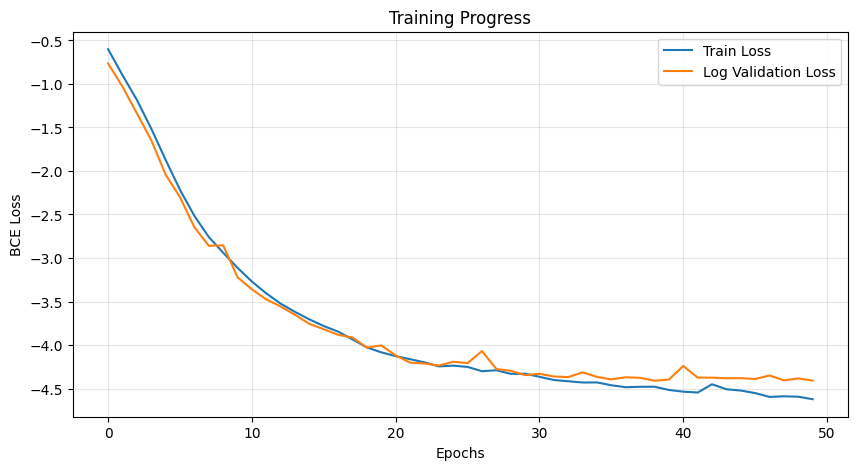

In [ ]:
#@title Loss Visualization

plt.figure(figsize=(10, 5))
plt.plot(np.log(train_losses), label='Train Loss')
plt.plot(np.log(val_losses), label='Log Validation Loss')
plt.title("Training Progress")
plt.xlabel("Epochs")
plt.ylabel("BCE Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Validation

In [ ]:
def get_picks_from_probs(probabilities, threshold=0.5):
    """
    Converts model probability output into discrete sample indices.
    Returns: (p_idx, s_idx)
    If max prob < threshold, returns -1 (no pick detected).
    """
    # probabilities shape: (2, 6000) for P and S
    p_probs = probabilities[0]
    s_probs = probabilities[1]

    p_max = np.max(p_probs)
    s_max = np.max(s_probs)

    p_pick = np.argmax(p_probs) if p_max > threshold else -1
    s_pick = np.argmax(s_probs) if s_max > threshold else -1

    return p_pick, s_pick

def evaluate_model(model, loader, device, sample_rate=100.0, threshold=0.5):
    model.eval()

    # Lists to store results
    y_true_cls = [] # 1 if event, 0 if noise
    y_pred_cls = []

    p_residuals = [] # Time difference in seconds
    s_residuals = []

    print("Running Inference on Validation Set...")

    with torch.no_grad():
        for batch in tqdm(loader):
            inputs = batch['x'].to(device)
            # We derive ground truth indices from the target masks
            target_masks = torch.stack([batch['y_p'], batch['y_s']], dim=1).numpy()

            # Forward pass
            outputs = model(inputs).cpu().numpy()

            for i in range(inputs.shape[0]):
                # --- 1. Extract Ground Truth Picks ---
                # Check if this sample is noise (all zeros) or event (has peak)
                gt_p_idx, gt_s_idx = get_picks_from_probs(target_masks[i])
                is_event_true = 1 if gt_p_idx != -1 else 0

                # --- 2. Extract Predicted Picks ---
                pred_p_idx, pred_s_idx = get_picks_from_probs(outputs[i], threshold=threshold)
                is_event_pred = 1 if pred_p_idx != -1 else 0

                # --- 3. Classification Metrics ---
                y_true_cls.append(is_event_true)
                y_pred_cls.append(is_event_pred)

                # --- 4. Regression Metrics (Residuals) ---
                # We only calculate residuals for True Positives (Event exists and was detected)
                if is_event_true and is_event_pred:
                    p_res_sec = (pred_p_idx - gt_p_idx) / sample_rate
                    p_residuals.append(p_res_sec)

                    # Check S-wave (sometimes S is harder to pick)
                    if gt_s_idx != -1 and pred_s_idx != -1:
                        s_res_sec = (pred_s_idx - gt_s_idx) / sample_rate
                        s_residuals.append(s_res_sec)

    return y_true_cls, y_pred_cls, p_residuals, s_residuals

# Run Evaluation
# Load best weights if available, otherwise use current
if os.path.exists("best_unet_model.pth"):
    model.load_state_dict(torch.load("best_unet_model.pth", map_location=device))

y_true, y_pred, p_res, s_res = evaluate_model(model, val_loader, device, threshold=0.2)

Running Inference on Validation Set...


100%|██████████| 13/13 [00:00<00:00, 32.28it/s]


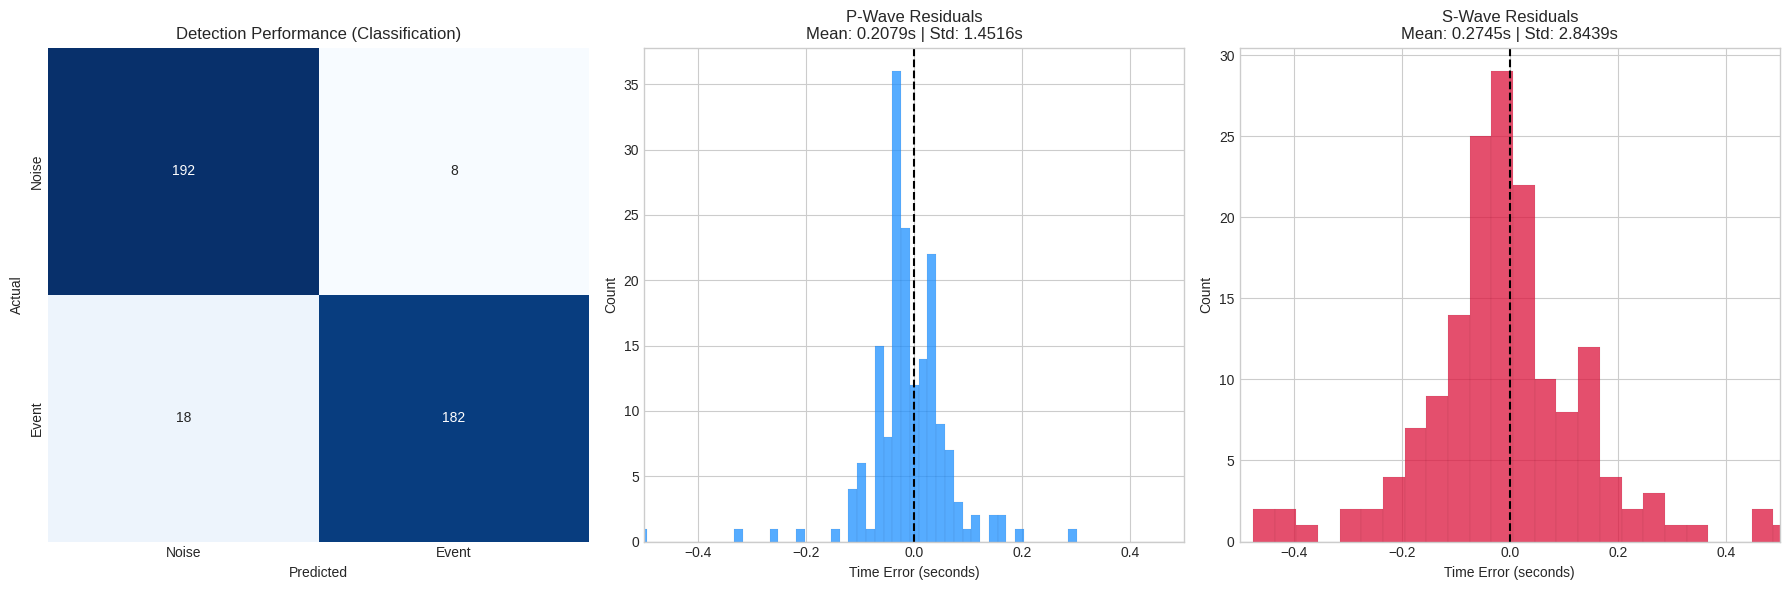


Classification Report:
              precision    recall  f1-score   support

       Noise       0.91      0.96      0.94       200
       Event       0.96      0.91      0.93       200

    accuracy                           0.94       400
   macro avg       0.94      0.94      0.93       400
weighted avg       0.94      0.94      0.93       400



In [ ]:
# Set plot style
plt.style.use('seaborn-v0_8-whitegrid')

def plot_metrics(y_true, y_pred, p_res, s_res):
    fig = plt.figure(figsize=(18, 6))
    gs = fig.add_gridspec(1, 3)

    # 1. Confusion Matrix
    ax1 = fig.add_subplot(gs[0, 0])
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax1,
                xticklabels=['Noise', 'Event'], yticklabels=['Noise', 'Event'])
    ax1.set_xlabel('Predicted')
    ax1.set_ylabel('Actual')
    ax1.set_title('Detection Performance (Classification)')

    # 2. P-Wave Residuals
    ax2 = fig.add_subplot(gs[0, 1])
    sns.histplot(p_res, bins=1000, color='dodgerblue', ax=ax2)
    ax2.set_title(f'P-Wave Residuals\nMean: {np.mean(p_res):.4f}s | Std: {np.std(p_res):.4f}s')
    ax2.set_xlabel('Time Error (seconds)')
    ax2.set_xlim(-0.5, 0.5) # Focus on the center
    ax2.axvline(0, color='k', linestyle='--')

    # 3. S-Wave Residuals
    ax3 = fig.add_subplot(gs[0, 2])
    sns.histplot(s_res, bins=1000, color='crimson', ax=ax3)
    ax3.set_title(f'S-Wave Residuals\nMean: {np.mean(s_res):.4f}s | Std: {np.std(s_res):.4f}s')
    ax3.set_xlabel('Time Error (seconds)')
    ax3.set_xlim(-0.5, 0.5)
    ax3.axvline(0, color='k', linestyle='--')

    plt.tight_layout()
    plt.show()

    # Print Classification Report
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=['Noise', 'Event']))

plot_metrics(y_true, y_pred, p_res, s_res)

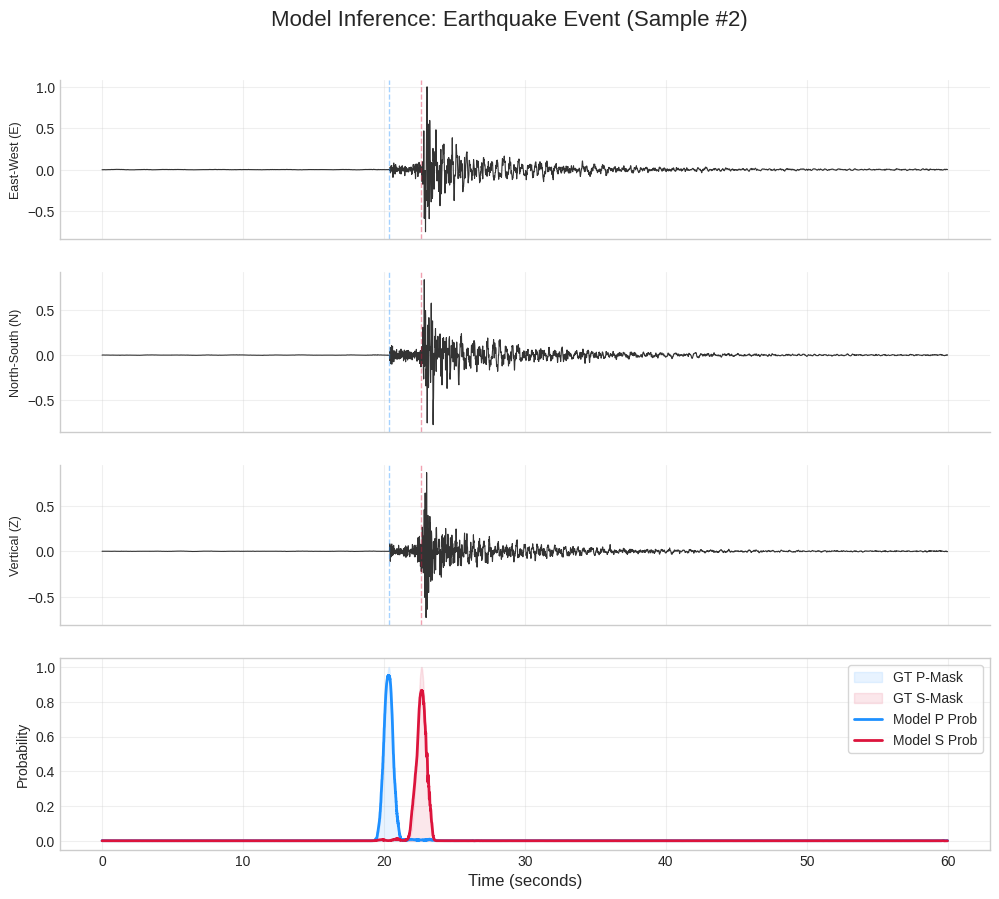

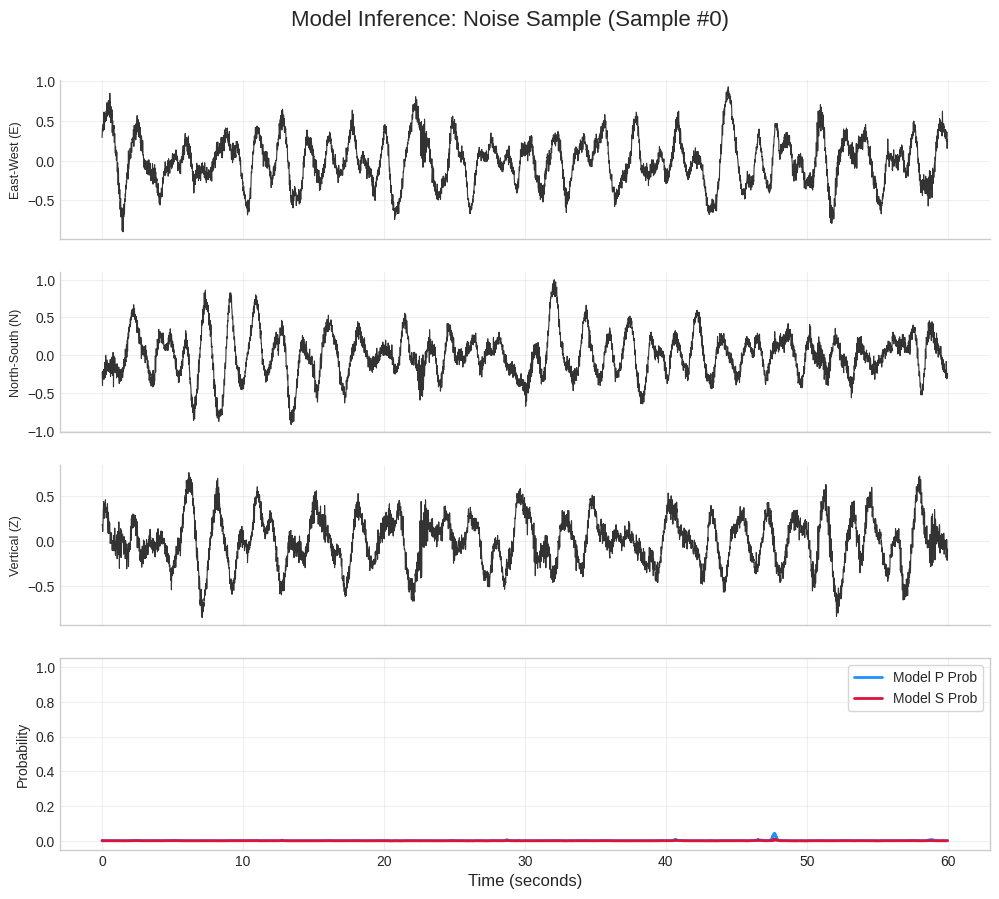

In [ ]:
def visualize_prediction(model, dataset, idx, device):
    """
    Plots the 3-component waveform alongside Ground Truth and Model Predictions.
    """
    model.eval()
    data = dataset[idx]
    x_tensor = data['x'].unsqueeze(0).to(device)

    # Get Prediction
    with torch.no_grad():
        preds = model(x_tensor).cpu().numpy()[0] # Shape (2, 6000)

    # Prepare Data for Plotting
    waveform = data['x'].numpy() # Shape (3, 6000)
    gt_p = data['y_p'].numpy()
    gt_s = data['y_s'].numpy()

    time = np.arange(waveform.shape[1]) / 100.0 # Time axis in seconds

    # Determine if it's an event based on GT
    is_event = np.max(gt_p) > 0.5
    title_text = "Earthquake Event" if is_event else "Noise Sample"

    # --- Plotting ---
    fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(12, 10), sharex=True,
                             gridspec_kw={'height_ratios': [1, 1, 1, 1.2]})

    channels = ['East-West (E)', 'North-South (N)', 'Vertical (Z)']
    colors = ['#333333', '#333333', '#333333']

    # Plot 3 Waveform Components
    for i in range(3):
        axes[i].plot(time, waveform[i], color=colors[i], linewidth=0.8)
        axes[i].set_ylabel(channels[i], fontsize=9)
        axes[i].grid(True, alpha=0.3)
        # Remove top and right spines for aesthetics
        axes[i].spines['top'].set_visible(False)
        axes[i].spines['right'].set_visible(False)

        # Add GT lines for reference on waveforms
        if is_event:
            p_loc = np.argmax(gt_p) / 100.0
            s_loc = np.argmax(gt_s) / 100.0
            axes[i].axvline(p_loc, color='dodgerblue', linestyle='--', alpha=0.4, lw=1)
            axes[i].axvline(s_loc, color='crimson', linestyle='--', alpha=0.4, lw=1)

    # Plot Probabilities (Masks)
    ax_prob = axes[3]

    # Plot Ground Truth Areas
    if is_event:
        ax_prob.fill_between(time, 0, gt_p, color='dodgerblue', alpha=0.1, label='GT P-Mask')
        ax_prob.fill_between(time, 0, gt_s, color='crimson', alpha=0.1, label='GT S-Mask')

    # Plot Model Predictions
    ax_prob.plot(time, preds[0], color='dodgerblue', linewidth=2, label='Model P Prob')
    ax_prob.plot(time, preds[1], color='crimson', linewidth=2, label='Model S Prob')

    ax_prob.set_ylabel("Probability", fontsize=10)
    ax_prob.set_xlabel("Time (seconds)", fontsize=12)
    ax_prob.set_ylim(-0.05, 1.05)
    ax_prob.legend(loc='upper right', frameon=True)
    ax_prob.grid(True, alpha=0.3)

    plt.suptitle(f"Model Inference: {title_text} (Sample #{idx})", fontsize=16, y=0.95)
    plt.show()

# Visualize a specific Event and a specific Noise sample from validation set
# Find an event index
event_indices = [i for i, x in enumerate(val_data) if x['y_p'].max() > 0.5]
noise_indices = [i for i, x in enumerate(val_data) if x['y_p'].max() < 0.5]

if event_indices:
    visualize_prediction(model, val_data, event_indices[0], device)
if noise_indices:
    visualize_prediction(model, val_data, noise_indices[0], device)